## Training Ridge Regression

<table>
        <thead>
            <tr>
                <th rowspan="2">Modelo</th>
                <th rowspan="2">Acurácia</th>
                <th colspan="2">Precisão</th>
                <th colspan="2">Recall</th>
                <th colspan="2">F1-Score</th>
            </tr>
            <tr>
                <th>Classe 0</th>
                <th>Classe 1</th>
                <th>Classe 0</th>
                <th>Classe 1</th>
                <th>Classe 0</th>
                <th>Classe 1</th>
            </tr>
        </thead>
        <tbody>
            <tr>
                <td>NB - All</td>
                <td>78%</td>
                <td>0.66</td>
                <td>0.82</td>
                <td>0.60</td>
                <td>0.86</td>
                <td>0.63</td>
                <td>0.84</td>
            </tr>
            <tr>
                <td>NB - Selected</td>
                <td>77%</td>
                <td>0.65</td>
                <td>0.82</td>
                <td>0.61</td>
                <td>0.85</td>
                <td>0.63</td>
                <td>0.84</td>
            </tr>
</table>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

##### Recovering the data

In [3]:
X_train = pd.read_csv("../../datasets/okx_datasets/X_train.csv")
X_test  = pd.read_csv("../../datasets/okx_datasets/X_test.csv")
y_train = pd.read_csv("../../datasets/okx_datasets/y_train.csv").values.ravel()
y_test  = pd.read_csv("../../datasets/okx_datasets/y_test.csv").values.ravel()

In [4]:
print("Shapes:")
print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

Shapes:
X_train: (180, 192)
X_test: (46, 192)
y_train: (180,)
y_test: (46,)


#### Training the RR with all variables

In [5]:
from sklearn.linear_model import RidgeClassifier
from sklearn.model_selection import GridSearchCV

In [6]:
rr = RidgeClassifier(random_state=42)

In [7]:
param_grid = {
    'alpha': [0.01, 0.1, 1.0, 10.0, 100.0],
    'fit_intercept': [True, False],
    'solver': ['auto', 'svd', 'cholesky', 'lsqr', 'sparse_cg', 'sag', 'saga'],
    'class_weight': [None, 'balanced']
}

In [8]:
# applying hyperparameter selection with Grid Search
grid = GridSearchCV(
    estimator=rr,
    param_grid=param_grid,
    cv=5,
    scoring="accuracy",
    n_jobs=-1,
    verbose=2
)

In [9]:
grid.fit(X_train, y_train)

Fitting 5 folds for each of 140 candidates, totalling 700 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RidgeClassifi...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'alpha': [0.01, 0.1, ...], 'class_weight': [None, 'balanced'], 'fit_intercept': [True, False], 'solver': ['auto', 'svd', ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and

In [10]:
print("Melhores hiperparâmetros encontrados:")
print(grid.best_params_)
print("\nMelhor score de validação:", grid.best_score_)

Melhores hiperparâmetros encontrados:
{'alpha': 10.0, 'class_weight': None, 'fit_intercept': True, 'solver': 'auto'}

Melhor score de validação: 0.7055555555555555


In [11]:
best_model = grid.best_estimator_
y_pred = best_model.predict(X_test)

##### Results of the model with all the features

In [12]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)
import seaborn as sns

In [13]:
acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred, average="weighted", zero_division=0)
rec = recall_score(y_test, y_pred, average="weighted", zero_division=0)
f1 = f1_score(y_test, y_pred, average="weighted", zero_division=0)

In [14]:
print("\n==================== MÉTRICAS ====================")
print(f"Acurácia:  {acc:.4f}")
print(f"Precisão:  {prec:.4f}")
print(f"Recall:    {rec:.4f}")
print(f"F1-score:  {f1:.4f}")


==================== MÉTRICAS ====================
Acurácia:  0.7391
Precisão:  0.7337
Recall:    0.7391
F1-score:  0.7209


In [15]:
print("\n==================== CLASSIFICATION REPORT ====================")
print(classification_report(y_test, y_pred, zero_division=0))


==================== CLASSIFICATION REPORT ====================
              precision    recall  f1-score   support

           0       0.75      0.43      0.55         7
           1       0.75      0.90      0.82        30
           2       0.67      0.44      0.53         9

    accuracy                           0.74        46
   macro avg       0.72      0.59      0.63        46
weighted avg       0.73      0.74      0.72        46



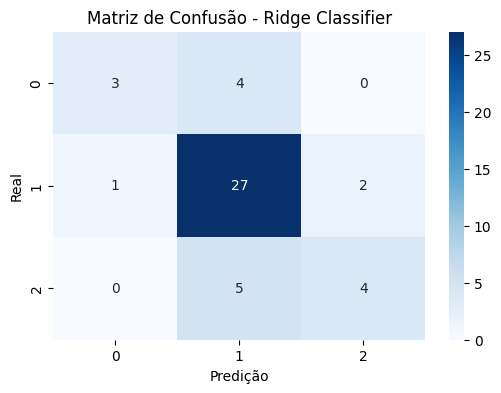

In [16]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Matriz de Confusão - Ridge Classifier")
plt.xlabel("Predição")
plt.ylabel("Real")
plt.show()

#### Training the RR with the K selected variables

In [17]:
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.pipeline import Pipeline

In [18]:
feature_names = X_train.columns.tolist()
n_features = X_train.shape[1]
k_values = list(range(1, n_features + 1))

In [19]:
pipe = Pipeline([
    ("select", SelectKBest(score_func=f_classif)),
    ("rr", RidgeClassifier(random_state=42))
])

In [20]:
param_grid = {
    "select__k": k_values,
    "rr__alpha": [0.01, 0.1, 1.0, 10.0, 100.0],
    "rr__solver": ['auto', 'saga', 'lsqr'],
    "rr__class_weight": [None, 'balanced']
}

In [21]:
grid = GridSearchCV(
    estimator=pipe,
    param_grid=param_grid,
    cv=5,
    scoring="accuracy",
    return_train_score=False,
    n_jobs=-1
)

In [22]:
grid.fit(X_train, y_train)
results = grid.cv_results_

print("\n Melhor combinação encontrada:")
print(grid.best_params_)

best_k = grid.best_params_["select__k"]
print(f"\n Melhor K encontrado: {best_k}")


 Melhor combinação encontrada:
{'rr__alpha': 0.01, 'rr__class_weight': None, 'rr__solver': 'auto', 'select__k': 74}

 Melhor K encontrado: 74


In [23]:
best_selector = grid.best_estimator_.named_steps["select"]
mask = best_selector.get_support()
selected_features = X_train.columns[mask].tolist()

print("\n Features selecionadas:")
for f in selected_features:
    print(" -", f)


 Features selecionadas:
 - Age
 - T-score Value
 - Z-Score Value
 - BMI: 
 - Gender_male
 - Diabetic_yes
 - Hypothyroidism_yes
 - Occupation _R.G.E
 - Occupation _R.g.e
 - Occupation _R.lecturer
 - Occupation _Teacher
 - Occupation _barber
 - Occupation _bussinesman
 - Occupation _clerk
 - Occupation _forest guard
 - Occupation _h.wife
 - Occupation _mobile technician
 - Occupation _nurse
 - Occupation _plumber
 - Occupation _student
 - Occupation _teacher
 - Occupation _worker
 - History of Fracture_L.foot
 - History of Fracture_R. wrist 
 - History of Fracture_both legs
 - History of Fracture_hip & head fracture
 - History of Fracture_hip injury
 - History of Fracture_knee replaced
 - History of Fracture_lab technician
 - History of Fracture_lumbar fracture
 - History of Fracture_neck fracture
 - History of Fracture_no
 - History of Fracture_shoulder fracture
 - History of Fracture_vertebral 
 - History of Fracture_vertebral fracture
 - History of Fracture_wrist
 - History of Fractu

In [24]:
X_train_sel = best_selector.transform(X_train)
X_test_sel  = best_selector.transform(X_test)

In [25]:
best_rr = grid.best_estimator_.named_steps["rr"]
best_rr.fit(X_train_sel, y_train)

,"alpha alpha: float, default=1.0Regularization strength; must be a positive float. Regularizationimproves the conditioning of the problem and reduces the variance ofthe estimates. Larger values specify stronger regularization.Alpha corresponds to ``1 / (2C)`` in other linear models such as:class:`~sklearn.linear_model.LogisticRegression` or:class:`~sklearn.svm.LinearSVC`.",0.01
,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If set to false, nointercept will be used in calculations (e.g. data is expected to bealready centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"max_iter max_iter: int, default=NoneMaximum number of iterations for conjugate gradient solver.The default value is determined by scipy.sparse.linalg.",None
,"tol tol: float, default=1e-4The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for each solver:- 'svd': `tol` has no impact.- 'cholesky': `tol` has no impact.- 'sparse_cg': norm of residuals smaller than `tol`.- 'lsqr': `tol` is set as atol and btol of scipy.sparse.linalg.lsqr, which control the norm of the residual vector in terms of the norms of matrix and coefficients.- 'sag' and 'saga': relative change of coef smaller than `tol`.- 'lbfgs': maximum of the absolute (projected) gradient=max|residuals| smaller than `tol`... versionchanged:: 1.2 Default value changed from 1e-3 to 1e-4 for consistency with other linear models.",0.0001
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None
,"solver solver: {'auto', 'svd', 'cholesky', 'lsqr', 'sparse_cg', 'sag', 'saga', 'lbfgs'}, default='auto'Solver to use in the computational routines:- 'auto' chooses the solver automatically based on the type of data.- 'svd' uses a Singular Value Decomposition of X to compute the Ridge coefficients. It is the most stable solver, in particular more stable for singular matrices than 'cholesky' at the cost of being slower.- 'cholesky' uses the standard scipy.linalg.solve function to obtain a closed-form solution.- 'sparse_cg' uses the conjugate gradient solver as found in scipy.sparse.linalg.cg. As an iterative algorithm, this solver is more appropriate than 'cholesky' for large-scale data (possibility to set `tol` and `max_iter`).- 'lsqr' uses the dedicated regularized least-squares routine scipy.sparse.linalg.lsqr. It is the fastest and uses an iterative procedure.- 'sag' uses a Stochastic Average Gradient descent, and 'saga' uses its unbiased and more flexible version named SAGA. Both methods use an iterative procedure, and are often faster than other solvers when both n_samples and n_features are large. Note that 'sag' and 'saga' fast convergence is only guaranteed on features with approximately the same scale. You can preprocess the data with a scaler from sklearn.preprocessing. .. versionadded:: 0.17 Stochastic Average Gradient descent solver. .. versionadded:: 0.19 SAGA solver.- 'lbfgs' uses L-BFGS-B algorithm implemented in `scipy.optimize.minimize`. It can be used only when `positive` is True.",'auto'
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive.Only 'lbfgs' solver is supported in this case.",False
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag' or 'saga' to shuffle the data.See :term:`Glossary ` for details.",42


In [26]:
y_pred = best_rr.predict(X_test_sel)

##### Results of the model with the selected features

In [27]:
acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred, average="weighted", zero_division=0)
rec = recall_score(y_test, y_pred, average="weighted", zero_division=0)
f1 = f1_score(y_test, y_pred, average="weighted", zero_division=0)

In [28]:
print("\n==================== MÉTRICAS MODELO FINAL ====================")
print(f"Acurácia:   {acc:.4f}")
print(f"Precisão:   {prec:.4f}")
print(f"Recall:     {rec:.4f}")
print(f"F1-score:   {f1:.4f}")


==================== MÉTRICAS MODELO FINAL ====================
Acurácia:   0.7174
Precisão:   0.7504
Recall:     0.7174
F1-score:   0.6788


In [29]:
print("\n==================== CLASSIFICATION REPORT ====================")
print(classification_report(y_test, y_pred, zero_division=0))


==================== CLASSIFICATION REPORT ====================
              precision    recall  f1-score   support

           0       1.00      0.14      0.25         7
           1       0.73      0.90      0.81        30
           2       0.62      0.56      0.59         9

    accuracy                           0.72        46
   macro avg       0.78      0.53      0.55        46
weighted avg       0.75      0.72      0.68        46



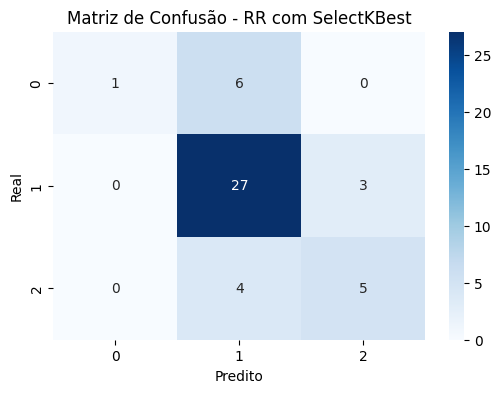

In [30]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Matriz de Confusão - RR com SelectKBest")
plt.xlabel("Predito")
plt.ylabel("Real")
plt.show()

In [31]:
from sklearn.model_selection import learning_curve

In [32]:
train_sizes, train_scores, val_scores = learning_curve(
    estimator=best_rr,
    X=X_train_sel,
    y=y_train,
    cv=5,
    scoring="accuracy",
    n_jobs=-1,
    train_sizes=np.linspace(0.1, 1.0, 10)
)

In [33]:
train_mean = train_scores.mean(axis=1)
train_std = train_scores.std(axis=1)
val_mean = val_scores.mean(axis=1)
val_std = val_scores.std(axis=1)

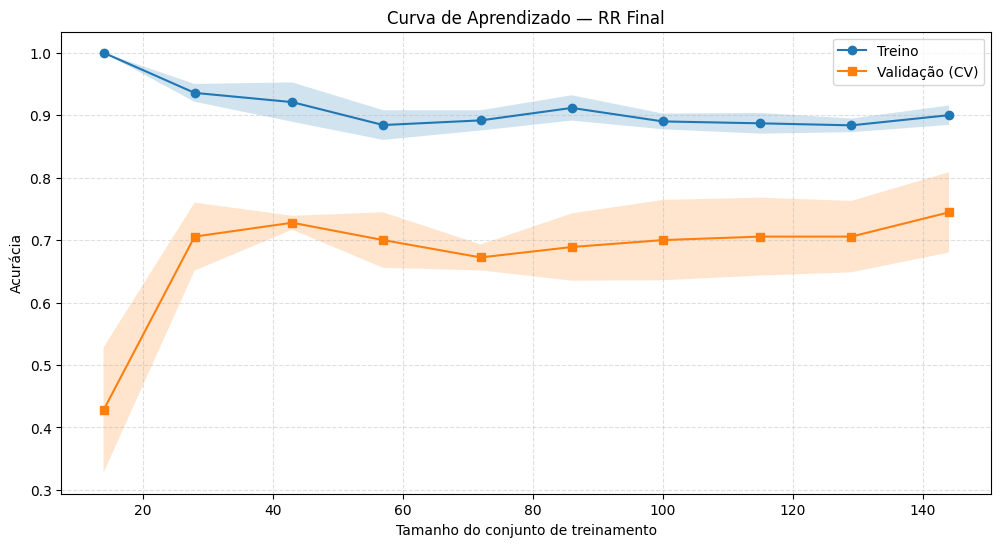

In [34]:
plt.figure(figsize=(12,6))
plt.plot(train_sizes, train_mean, marker="o", label="Treino")
plt.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.2)

plt.plot(train_sizes, val_mean, marker="s", label="Validação (CV)")
plt.fill_between(train_sizes, val_mean - val_std, val_mean + val_std, alpha=0.2)

plt.title("Curva de Aprendizado — RR Final")
plt.xlabel("Tamanho do conjunto de treinamento")
plt.ylabel("Acurácia")
plt.grid(True, linestyle="--", alpha=0.4)
plt.legend()
plt.show()